In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)

In [10]:
df = pd.read_csv(r"C:\Users\JAY PATEL\Desktop\Practice\Supervised\USA_Housing.csv")

In [12]:
print("Dataset shape:", df.shape)
print(df.head())
print("\nColumns:", list(df.columns))

Dataset shape: (5000, 7)
   Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0      79545.458574             5.682861                   7.009188   
1      79248.642455             6.002900                   6.730821   
2      61287.067179             5.865890                   8.512727   
3      63345.240046             7.188236                   5.586729   
4      59982.197226             5.040555                   7.839388   

   Avg. Area Number of Bedrooms  Area Population         Price  \
0                          4.09     23086.800503  1.059034e+06   
1                          3.09     40173.072174  1.505891e+06   
2                          5.13     36882.159400  1.058988e+06   
3                          3.26     34310.242831  1.260617e+06   
4                          4.23     26354.109472  6.309435e+05   

                                             Address  
0  208 Michael Ferry Apt. 674\nLaurabury, NE 3701...  
1  188 Johnson Views Suite 079\nLake Kath

In [13]:
df = df.drop(columns=['Address'])

In [7]:
print("\nMissing Values:\n",hp.isnull().sum().sum())


Missing Values:
 0


In [ ]:
median_price = df['Price'].median()
df['PriceCategory'] = (df['Price'] > median_price).astype(int)  
 
print(f"\nMedian house price: ${median_price:,.0f}")
print(df['PriceCategory'].value_counts())


Median house price: $1,232,669
PriceCategory
0    2500
1    2500
Name: count, dtype: int64


In [15]:
X = df.drop(columns=['Price', 'PriceCategory'])
y = df['PriceCategory']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

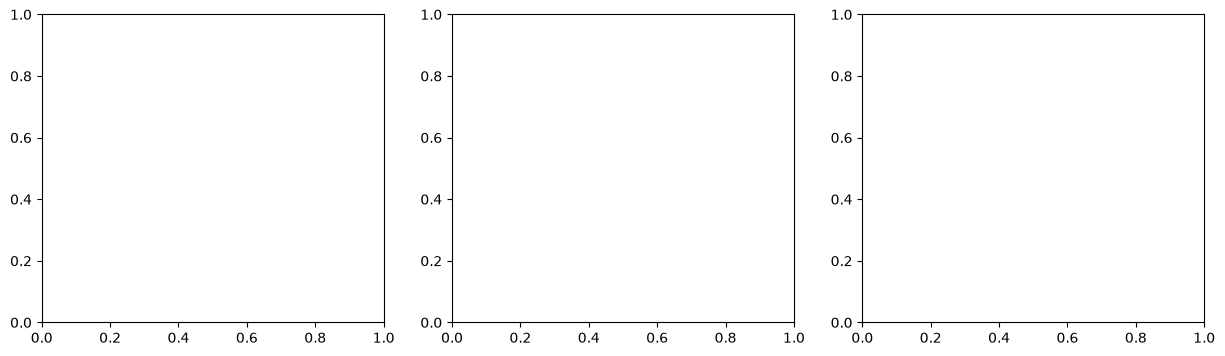

In [19]:
results = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 

In [21]:
for idx, (name, model) in enumerate(models.items()):
    if name == "Random Forest":
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
 
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
 
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "False Positives": fp,
        "False Negatives": fn
    })
 
    print(f"\n{'='*55}")
    print(f"Model: {name}")
    print(f"{'='*55}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"False Positives: {fp} | False Negatives: {fn}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Not Expensive', 'Expensive']))
 
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Not Expensive', 'Expensive'],
                yticklabels=['Not Expensive', 'Expensive'])
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
 
plt.tight_layout()
plt.savefig('confusion_matrices_real_data.png', dpi=120)
plt.close()
 


Model: Logistic Regression
Accuracy : 0.9160
Precision: 0.9015
Recall   : 0.9340
F1-Score : 0.9175
False Positives: 51 | False Negatives: 33

Classification Report:
               precision    recall  f1-score   support

Not Expensive       0.93      0.90      0.91       500
    Expensive       0.90      0.93      0.92       500

     accuracy                           0.92      1000
    macro avg       0.92      0.92      0.92      1000
 weighted avg       0.92      0.92      0.92      1000


Model: KNN
Accuracy : 0.8750
Precision: 0.8613
Recall   : 0.8940
F1-Score : 0.8773
False Positives: 72 | False Negatives: 53

Classification Report:
               precision    recall  f1-score   support

Not Expensive       0.89      0.86      0.87       500
    Expensive       0.86      0.89      0.88       500

     accuracy                           0.88      1000
    macro avg       0.88      0.88      0.87      1000
 weighted avg       0.88      0.88      0.87      1000


Model: Random For

In [22]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="False Positives")
 
print(f"\n{'='*70}")
print("SUMMARY: MODEL COMPARISON on REAL Kaggle Data (sorted by fewest FP)")
print(f"{'='*70}")
print(results_df.to_string(index=False))
 
best_model = results_df.iloc[0]["Model"]
best_fp = results_df.iloc[0]["False Positives"]
print(f"\n>>> Model with LEAST False Positives: {best_model} (FP = {best_fp}) <<<")
 


SUMMARY: MODEL COMPARISON on REAL Kaggle Data (sorted by fewest FP)
              Model  Accuracy  Precision  Recall  F1-Score  False Positives  False Negatives
Logistic Regression     0.916     0.9015   0.934    0.9175               51               33
Logistic Regression     0.916     0.9015   0.934    0.9175               51               33
      Random Forest     0.893     0.8786   0.912    0.8950               63               44
      Random Forest     0.893     0.8786   0.912    0.8950               63               44
                KNN     0.875     0.8613   0.894    0.8773               72               53
                KNN     0.875     0.8613   0.894    0.8773               72               53

>>> Model with LEAST False Positives: Logistic Regression (FP = 51) <<<


In [23]:
plt.figure(figsize=(6, 4))
colors = ['#2ecc71' if m == best_model else '#e74c3c' for m in results_df['Model']]
plt.bar(results_df['Model'], results_df['False Positives'], color=colors)
plt.title('False Positives by Model - Real Kaggle Data (lower is better)')
plt.ylabel('False Positives Count')
plt.tight_layout()
plt.savefig('false_positives_real_data.png', dpi=120)
plt.close()
 
results_df.to_csv('model_comparison_real_data_summary.csv', index=False)
 
print("\nSaved: confusion_matrices_real_data.png, false_positives_real_data.png, model_comparison_real_data_summary.csv")


Saved: confusion_matrices_real_data.png, false_positives_real_data.png, model_comparison_real_data_summary.csv


In [25]:
git --version

NameError: name 'git' is not defined